# Score Dashboard

`scripts/rank_all.sh` 実行後のランキング結果を可視化するノートブック。

### Agent Response スコア定義
| Label | Key | 説明 |
|-------|-----|------|
| Score 1 | `best_avg_similarity` | Best (rating=5) golden response → 全 new responses の平均類似度 |
| Score 2 | `average_similarity` | Golden × New 全ペアの類似度行列の平均 |
| Score 4 | `avg_vs_avg_similarity` | Golden 平均ベクトル vs New 平均ベクトルのコサイン類似度 |

### Follow-up Question スコア定義

各 run には 3 つの follow-up question が生成される。マスターの `ok_follow_up_list` に含まれる正解 follow-up とコサイン類似度で比較する。

| カラム | 説明 |
|--------|------|
| `n_ok_follow_ups` | マスターに登録されている OK follow-up question の数 |
| `per_run_max_sims` | 各 run ごとに、生成された 3 つの follow-up question それぞれの最大類似度をリスト表示。例: `{"run0": [0.5, 0.4, 0.3], "run1": [0.2, 0.1, 0.9]}` |
| `follow_up_score` | 各 run で 3 つの最大類似度のうち **最大値** → 全 run の平均。例: run0 max=0.5, run1 max=0.9 → (0.5+0.9)/2=0.7 |
| `follow_up_avg_similarity` | 各 run で 3 つの最大類似度の **平均** → 全 run の平均。例: run0 mean=0.4, run1 mean=0.4 → (0.4+0.4)/2=0.4 |
| `best_run_id` | agent_response で golden best (rating=5) に最も類似した new run の ID |
| `best_run_fu_sims` | その best run の 3 つの follow-up の最大類似度リスト。例: `[0.5, 0.4, 0.3]` |
| `best_run_fu_avg` | `best_run_fu_sims` の平均。例: mean(0.5, 0.4, 0.3) = 0.4 |

In [1]:
%load_ext autoreload
%autoreload 2

DATA_DIR = "data/baseline"
LABEL = "Baseline"

## Baseline

`data/baseline` — 23 conversations

,conversation_name,best_id,average_similarity,avg_vs_avg_similarity,best_avg_similarity
0,こんにちは_20回_free_v02_100064_20260218_162721,1,0.8371,1.0000,0.8663
1,こんにちは_20回_free_v02_100064_20260218_162721,4,0.8371,1.0000,0.8650
2,こんにちは_case1-1_20回_free_v02_100064_20260223_144550,2,0.8785,1.0000,0.8695
3,こんにちは_case1_20回_free_v02_100064_20260220_002408,15,0.8386,1.0000,0.8521
4,こんにちは_case2-1_20回_free_v02_100064_20260223_150334,4,0.8522,1.0000,0.8353
5,こんにちは_case2_20回_free_v02_100064_20260220_004213,12,0.8278,1.0000,0.8063
6,前年比較_20回_free_v02_307132_20260218_163653,8,0.8545,1.0000,0.8779
7,前年比較_20回_free_v02_307132_20260218_163653,16,0.8545,1.0000,0.8567
8,前年比較_case1_20回_free_v02_307132_20260220_010734,3,0.8261,1.0000,0.8705
9,前年比較_case2-1_20回_free_v02_307132_20260223_155528,9,0.8797,1.0000,0.8576


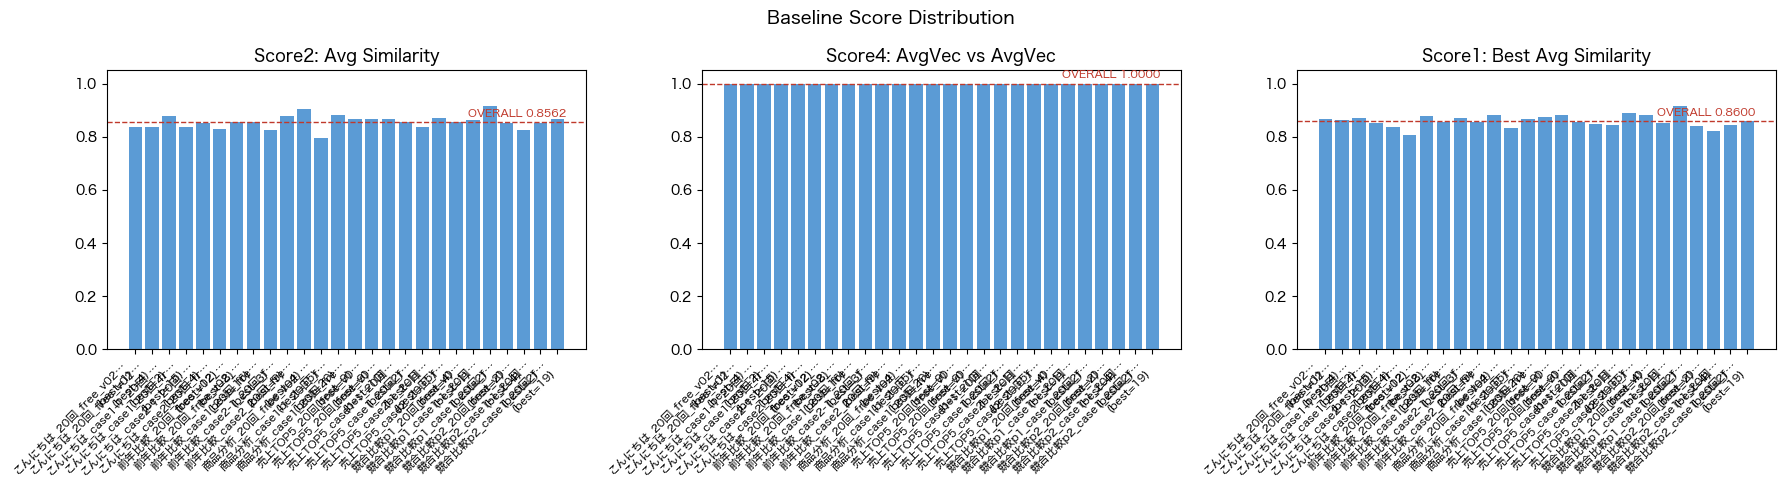

In [2]:
from notebooks.utils.display import show_scores

show_scores(DATA_DIR, label=LABEL)

In [3]:
from notebooks.utils.display import show_follow_up_scores

show_follow_up_scores(DATA_DIR, label=LABEL)

## Baseline — Follow-up Question Similarity

`data/baseline` — 23 conversations

,conversation_name,n_ok_follow_ups,per_run_max_sims,follow_up_score,follow_up_avg_similarity,best_run_id,best_run_fu_sims,best_run_fu_avg
0,こんにちは_20回_free_v02_100064_20260218_162721,18,"{'run1': [0.5629, 1.0, 1.0], 'run2': [0.5786, 0.8753, 0.7153], 'run4': [1.0, 1.0, 1.0], 'run5': [0.6849, 0.9885, 1.0], 'run6': [0.5724, 0.9923, 0.6315], 'run7': [0.5929, 0.4048, 0.3666], 'run8': [0.5924, 0.4229, 0.5178], 'run9': [0.6002, 1.0, 1.0], 'run10': [0.6446, 0.9885, 0.9811], 'run12': [0.4565, 0.5606, 0.4009], 'run13': [0.5629, 0.824, 1.0], 'run15': [0.4597, 0.5738, 0.7351], 'run16': [0.5955, 0.8336, 0.8106], 'run18': [0.3961, 0.5588, 0.4465], 'run20': [0.5629, 0.7453, 0.7511]}",0.8320,0.7108,1,"[0.5629, 1.0, 1.0]",0.8543
1,こんにちは_case1-1_20回_free_v02_100064_20260223_144550,2,"{'run1': [0.2441, 0.6322, 0.225], 'run2': [1.0, 1.0, 0.2647], 'run3': [0.8527, 0.6008, 0.2001], 'run4': [0.627, 0.5823, 0.2775], 'run5': [0.7143, 0.3771, 0.2769], 'run6': [0.852, 0.3971, 0.2143], 'run7': [1.0, 0.2375, 0.5912], 'run8': [0.5928, 0.2507, 0.5641], 'run9': [0.5644, 0.2459, 0.5695], 'run10': [0.5709, 0.4409, 0.5856], 'run11': [0.6206, 0.6512, 0.5165], 'run12': [0.4457, 0.5553, 0.5736], 'run13': [0.6001, 0.5556, 0.5003], 'run14': [0.8272, 0.4014, 0.2564], 'run15': [0.8529, 0.7329, 0.2775], 'run16': [0.6201, 0.4512, 0.5559], 'run17': [0.5772, 0.6766, 0.2234], 'run18': [0.8171, 0.5834, 0.5595], 'run19': [0.9664, 0.2146, 0.5228], 'run20': [0.2064, 0.5834, 0.4663]}",0.7297,0.5324,2,"[1.0, 1.0, 0.2647]",0.7549
2,こんにちは_case1_20回_free_v02_100064_20260220_002408,6,"{'run1': [0.8299, 0.966, 0.7186], 'run2': [0.7998, 0.4849, 0.4705], 'run3': [0.867, 0.4876, 0.8263], 'run4': [0.6034, 0.8536, 0.7451], 'run5': [0.7934, 0.5289, 0.7672], 'run6': [0.5073, 0.6496, 0.7747], 'run7': [0.4186, 0.6554, 0.5947], 'run8': [0.9032, 1.0, 0.6976], 'run9': [0.867, 0.738, 1.0], 'run10': [0.636, 0.6407, 0.8922], 'run11': [0.6071, 0.7287, 0.8126], 'run12': [0.8445, 0.7263, 0.7129], 'run13': [0.5837, 0.6292, 0.6934], 'run14': [0.9683, 0.6707, 1.0], 'run15': [1.0, 1.0, 1.0], 'run16': [0.8536, 0.7814, 0.5178], 'run17': [0.8957, 0.7828, 0.5195], 'run18': [0.8555, 0.6193, 0.7327], 'run19': [0.8299, 1.0, 0.743], 'run20': [0.6943, 0.4661, 0.7913]}",0.8674,0.7463,15,"[1.0, 1.0, 1.0]",1.0000
3,こんにちは_case2-1_20回_free_v02_100064_20260223_150334,2,"{'run1': [0.1652, 0.2929, 0.2999], 'run2': [0.4457, 0.2062, 0.3312], 'run3': [0.848, 0.695, 0.2507], 'run4': [1.0, 1.0, 0.3779], 'run5': [0.973, 0.8899, 0.3406], 'run6': [0.5672, 0.424, 0.3766], 'run7': [0.9544, 0.8361, 0.3768], 'run8': [0.8979, 0.2705, 0.3449], 'run9': [0.961, 0.3406, 0.3626], 'run10': [0.9142, 0.9202, 0.339], 'run11': [0.9544, 0.3576, 0.2584], 'run12': [0.9552, 0.3893, 0.23], 'run13': [0.973, 0.6224, 0.2953], 'run14': [0.7933, 0.123, 0.8414], 'run15': [0.9186, 0.7391, 0.3353], 'run16': [0.9029, 0.3406, 0.3664], 'run17': [0.2999, 0.3638, 0.257], 'run18': [0.9343, 0.6392, 0.3282], 'run19': [0.9143, 0.3696, 0.2834], 'run20': [0.9186, 0.6643, 0.2671]}",0.8272,0.5606,4,"[1.0, 1.0, 0.3779]",0.7926
4,こんにちは_case2_20回_free_v02_100064_20260220_004213,1,"{'run1': [0.8675, 0.5315, 0.3221], 'run2': [0.5983, 0.4127, 0.2935], 'run3': [0.3944, 0.5536, 0.6587], 'run4': [0.4326, 0.5702, 0.5712], 'run5': [0.5437, 0.292, 0.5538], 'run6': [0.3192, 0.5702, 0.347], 'run7': [0.3169, 0.5702, 0.3119], 'run8': [0.5983, 0.5894, 0.3238], 'run9': [0.5524, 0.3646, 0.3023], 'run10': [0.2947, 0.3438, 0.5697], 'run11': [0.5819, 0.3246, 0.2473], 'run12': [1.0, 0.3343, 0.314], 'run13': [0.3727, 0.6265, 0.3499], 'run14': [0.5692, 0.589, 0.6623], 'run15': [0.5396, 0.589, 0.478], 'run16': [0.8288, 0.3481, 0.4443], 'run17': [0.5524, 0.3478, 0.5713], 'run18': [0.8687, 0.5044, 0.3532], 'run19': [0.6065, 0.1881, 0.333], 'run20': [0.5696, 0.6357, 0.285]}",0.6541,0.4831,12,"[1.0, 0.3343, 0.314]",0.5494
5,前年比較_20回_free_v02_307132_20260218_163653,7,"{'run1': [0.8738, 0.8652, 0.944], 'run2': [0.766, 0.7491, 0.5815], 'run3': [0.8035, 0.6246, 0.6212], 'run8': [1.0, 1.0, 1.0], 'run10': 